In [25]:
#Q7.1

import numpy as np
import numpy.linalg as la
from numpy.linalg import inv

A = np.array([[1, 2, 3],[0, -4, 1],[0, 3, -1]]).reshape(3,3)
print(A)

det = la.det(A)
print(f'The determinant of A is {det}')

B = np.array([2,2,-1]).reshape(3,1)
print(B)

solu = inv(A)@B
C = solu.reshape(1,3)
print(f'The solution is (x, y, z) = ({C})')

AT_A = A.T@A
I = np.eye(3)

if np.allclose(AT_A, I):
    print("A is orthogonal")
else:
    print("A is NOT orthogonal")

eigenvalues = la.eigvals(A)
print(f"The eigenvalues of A are {eigenvalues}")

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
The determinant of A is 1.0
[[ 2]
 [ 2]
 [-1]]
The solution is (x, y, z) = ([[10. -1. -2.]])
A is NOT orthogonal
The eigenvalues of A are [ 1.         -4.79128785 -0.20871215]


In [34]:
#Q7.3
import numpy as np
E = np.array([[-0.06698874, -0.87275577, -0.48353891],
[ 0.49272847, -0.45034696,  0.74458463],
[-0.86760081, -0.1883746,   0.46019978]]).reshape(3,3)
print(E)

# Check orthogonality
print(np.allclose(E.T @ E, np.eye(3)))
# Check determinant
print(np.linalg.det(E))

eigvals = np.linalg.eigvals(E)
print(eigvals)

alpha = np.deg2rad(192.25)
delta = np.deg2rad(27.4)

v = np.array([
    np.cos(delta)*np.cos(alpha),
    np.cos(delta)*np.sin(alpha),
    np.sin(delta)
])

print(v)
print(np.linalg.norm(v))
v2 = E @ v
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
True
0.9999999982754763
[-0.52856796+0.84889099j -0.52856796-0.84889099j  0.99999999+0.j        ]
[-0.86760081 -0.1883746   0.46019978]
1.0
[ 3.42052506e-09 -4.54291366e-09  9.99999996e-01]


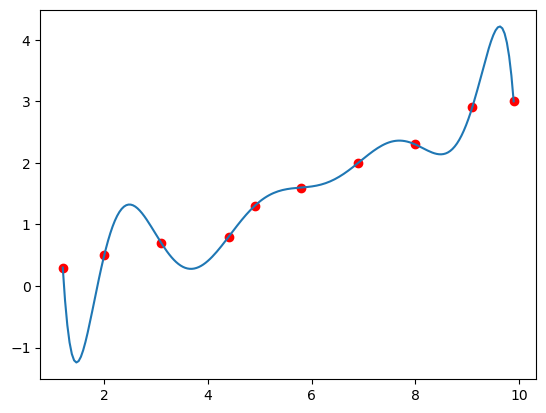

In [35]:
#Q7.5
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
n = len(x)

# Vandermonde matrix (with loops)
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A[i, j] = x[i]**j

# Solve Ac = y
c = np.linalg.solve(A, y)

# Plot
xp = np.linspace(min(x), max(x), 200)
yp = sum(c[j] * xp**j for j in range(n))

plt.scatter(x, y, color='red')
plt.plot(xp, yp)
plt.show()

Text(0.5, 1.0, 'Interpolation comparison')

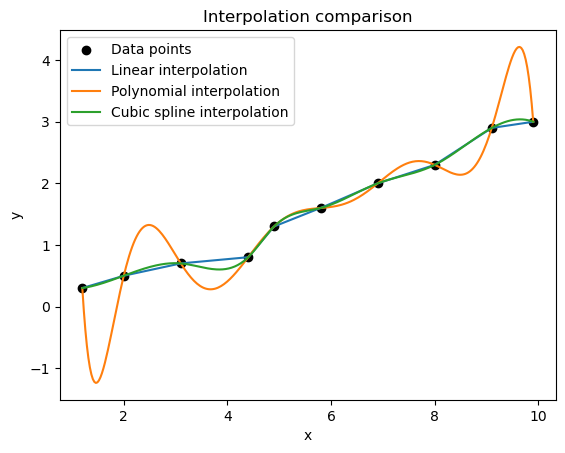

In [39]:
#Q7.6
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip
from scipy.interpolate import interp1d

class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.n = len(x)
        
        # Polynomial coefficients (degree n-1)
        # Using Vandermonde matrix and solve
        A = np.vander(x, increasing=True)
        self.poly_coeffs = np.linalg.solve(A, y)
        
        # Create cubic spline function using interp1d
        self.spline_func = interp1d(x, y, kind='cubic')
        
        # Linear interpolation function using interp1d
        self.linear_func = interp1d(x, y, kind='linear')
    
    def ip(self, X, method='spline'):
        if method == 'linear':
            return self.linear_func(X)
        elif method == 'polynomial':
            # Evaluate polynomial at X
            powers = np.array([X**i for i in range(self.n)])
            return np.dot(self.poly_coeffs, powers)
        elif method == 'spline':
            return self.spline_func(X)
        else:
            raise ValueError("Method must be 'linear', 'polynomial', or 'spline'")

# Example usage
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

interp = Interpolation(x, y)

X_plot = np.linspace(x.min(), x.max(), 300)

# Interpolated values
y_linear = interp.ip(X_plot, method='linear')
y_poly = interp.ip(X_plot, method='polynomial')
y_spline = interp.ip(X_plot, method='spline')

# Plotting
plt.scatter(x, y, color='black', label='Data points')
plt.plot(X_plot, y_linear, label='Linear interpolation')
plt.plot(X_plot, y_poly, label='Polynomial interpolation')
plt.plot(X_plot, y_spline, label='Cubic spline interpolation')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolation comparison')

In [41]:
#7.7
import numpy as np

I = np.array([[2.0, 4.1],
              [2.5, 3.8]])

x = 0.2  # lambda
y = 0.7  # mu

I0 = I[0,0]
I1 = I[0,1]
I2 = I[1,0]
I3 = I[1,1]

I_ip = (1 - x)*(1 - y)*I0 + x*(1 - y)*I1 + y*(1 - x)*I2 + x*y*I3
print(f"Interpolated intensity I_ip = {I_ip}")

Interpolated intensity I_ip = 2.658


leastsq fit parameters: a=64.132, b=69.938
curve_fit parameters: a=64.132, b=69.938


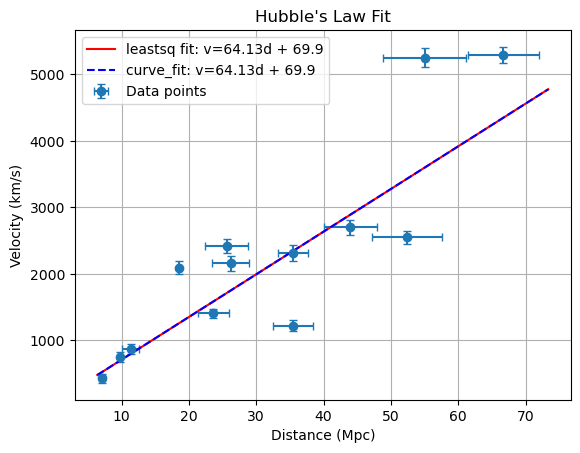

In [42]:
#7.10

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# Raw data: d (Mpc), v (km/s), error_d, error_v
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

# Reshape data to columns
data = np.array(data).reshape(-1,4)
d = data[:,0]  # distances
v = data[:,1]  # velocities
err_d = data[:,2]
err_v = data[:,3]

# Define linear model y = a*x + b
def linear_model(params, x):
    a, b = params
    return a*x + b

# Residuals function for leastsq (weighted by velocity errors)
def residuals(params, x, y, y_err):
    return (y - linear_model(params, x)) / y_err

# Initial guess for parameters a,b
p0 = [50, 0]

# Least squares fitting with velocity uncertainties
result = leastsq(residuals, p0, args=(d, v, err_v), full_output=1)
p_opt = result[0]
print(f"leastsq fit parameters: a={p_opt[0]:.3f}, b={p_opt[1]:.3f}")

# Use curve_fit with sigma=velocity uncertainties
def lin_func(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin_func, d, v, sigma=err_v, absolute_sigma=True)
print(f"curve_fit parameters: a={popt[0]:.3f}, b={popt[1]:.3f}")

# Plot data and fits
plt.errorbar(d, v, yerr=err_v, xerr=err_d, fmt='o', label='Data points', markersize=6, capsize=3)

# Smooth x for plotting fits
x_fit = np.linspace(min(d)*0.9, max(d)*1.1, 300)

# Plot leastsq fit
plt.plot(x_fit, linear_model(p_opt, x_fit), 'r-', label=f'leastsq fit: v={p_opt[0]:.2f}d + {p_opt[1]:.1f}')

# Plot curve_fit fit
plt.plot(x_fit, lin_func(x_fit, *popt), 'b--', label=f'curve_fit: v={popt[0]:.2f}d + {popt[1]:.1f}')

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title("Hubble's Law Fit")
plt.legend()
plt.grid()
plt.show()

In [8]:
#7.14